# Taller Evaluativo 1: Redes Multicapa y Diagnostico de Modelos
**Especializacion en Ciencia de Datos e Inteligencia Artificial - Universidad de Medellin**  
**Modulo: Deep Learning - Semana 1**

---

## Contexto de Negocio: Retencion de Clientes (Telco Churn)

Somos el equipo de analitica de una empresa de telecomunicaciones. El departamento de marketing esta preocupado porque muchos clientes estan cancelando sus servicios (**Churn**). Adquirir un nuevo cliente es mucho mas costoso que retener a uno actual, por lo que nos piden un modelo de Deep Learning que prediga que clientes tienen alta probabilidad de irse, basandose en su comportamiento historico.

**Dataset:** Telco Customer Churn (IBM/Kaggle)  
**Variable objetivo (Target):** `Churn` - Yes = 1 / No = 0

## Importaciones Generales

Antes de escribir una sola linea de modelo, importamos las herramientas que usaremos a lo largo del taller. Entender **para que sirve cada libreria** es parte del aprendizaje:

| Libreria | Rol en este proyecto |
|---|---|
| `numpy` | Operaciones matematicas sobre arrays; base de todo calculo numerico en Python |
| `pandas` | Carga, inspeccion y transformacion del dataset tabular (CSV) |
| `matplotlib` / `seaborn` | Visualizacion de curvas de entrenamiento y matriz de confusion |
| `sklearn` | Split train/val/test, escalado con StandardScaler y metricas de evaluacion |
| `tensorflow` / `keras` | Framework de Deep Learning: define, compila y entrena las redes neuronales |

> **Nota de versiones:** TensorFlow 2.x incluye Keras como su API de alto nivel (`tf.keras`). No es necesario instalar Keras por separado.

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print(f'TensorFlow version: {tf.__version__}')
print(f'NumPy version: {np.__version__}')
print(f'Pandas version: {pd.__version__}')

TensorFlow version: 2.21.0
NumPy version: 2.4.2
Pandas version: 3.0.1


---
## PASO 1 - Preparacion de Datos

La calidad del dato es el factor mas critico en cualquier proyecto de Machine Learning. Un modelo entrenado sobre datos sucios o mal preparados producira predicciones erroneas sin importar cuan sofisticada sea su arquitectura. Este principio se resume en el adagio del campo: **"Garbage in, garbage out"**.

En este paso aplicamos el pipeline estandar de preparacion:

1. **Carga del dataset** desde la fuente original (Kaggle)
2. **Exploracion inicial (EDA)** para entender la estructura y detectar anomalias
3. **Limpieza** de valores erroneos o inconsistentes
4. **Codificacion** de variables categoricas a formato numérico
5. **Split y escalado** para preparar los datos para el entrenamiento

### 1.1 Descarga del dataset con kagglehub

Usamos `kagglehub` para descargar el dataset directamente desde Kaggle sin necesidad de hacerlo manualmente. La libreria gestiona una cache local: si el dataset ya fue descargado anteriormente, lo reutiliza sin volver a descargarlo.

**Requisito:** tener las credenciales de Kaggle configuradas en `~/.kaggle/kaggle.json` o haber iniciado sesion con `kaggle auth login`.

In [ ]:
import kagglehub
import os
from IPython.display import display

# Descarga la version mas reciente del dataset en la cache local de kagglehub
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("Archivos descargados en:", path)
print(os.listdir(path))

# Cargamos el CSV con pandas
ruta_csv = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(ruta_csv)

print(f'\nForma del dataset: {df.shape}  ({df.shape[0]} clientes, {df.shape[1]} columnas)')

print('\nPrimeros 10 registros:')
display(df.head(10))

print('\n6 registros aleatorios:')
display(df.sample(6, random_state=42))

### 1.2 Exploracion inicial (EDA)

El Analisis Exploratorio de Datos (EDA, por sus siglas en ingles) es el primer paso obligatorio antes de cualquier transformacion. Nos permite responder tres preguntas clave:

- **Que tipo de datos tenemos?** — numericos continuos, categoricos, binarios
- **Hay datos faltantes o corruptos?** — columnas con NaN o valores invalidos
- **Esta balanceado el target?** — si hay muchos mas "No Churn" que "Churn", el modelo puede sesgarse a predecir siempre la clase mayoritaria

El desbalance de clases es especialmente relevante en problemas de churn: en la mayoria de empresas, la tasa de abandono es del 15-30%, lo que crea un dataset asimetrico que afecta directamente las metricas y el comportamiento del modelo.

In [47]:
print('Tipos de datos:')
print(df.dtypes)
print('\nValores nulos por columna:')
print(df.isnull().sum())
print('\nDistribucion del target (Churn):')
print(df['Churn'].value_counts())

Tipos de datos:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Valores nulos por columna:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Pa

#### 1.2.1 Deteccion de Anomalias

Inspeccionamos columnas con posibles problemas antes de la limpieza:
- **Espacios en blanco** en columnas de texto que deberian ser numericas
- **Valores no numericos** en columnas continuas
- **Categorias inesperadas** en columnas categoricas

In [48]:
# --- 1. Columnas object que deberian ser numericas ---
cols_object = df.select_dtypes(include='object').columns.tolist()
print('Columnas de tipo object:', cols_object)

# --- 2. Espacios en blanco en columnas object ---
print('\n--- Filas con espacios en blanco (solo espacios) por columna ---')
espacios_encontrados = False
for col in cols_object:
    mask = df[col].str.strip() == ''
    n = mask.sum()
    if n > 0:
        print(f'  {col}: {n} filas con valor en blanco')
        espacios_encontrados = True
if not espacios_encontrados:
    print('  Ninguna columna de texto tiene valores en blanco puro.')

# --- 3. Valores no numericos en TotalCharges (esperada como float) ---
print('\n--- Valores no numericos en TotalCharges ---')
no_numericos = pd.to_numeric(df['TotalCharges'], errors='coerce').isna()
print(f'  Filas donde TotalCharges no es numerico: {no_numericos.sum()}')
if no_numericos.sum() > 0:
    print(df.loc[no_numericos, ['customerID', 'tenure', 'TotalCharges']].head(10))

# --- 4. Categorias unicas en columnas binarias (esperamos exactamente 2) ---
print('\n--- Categorias inesperadas en columnas binarias ---')
cols_binarias = [c for c in cols_object if df[c].nunique() <= 4 and c != 'customerID']
for col in cols_binarias:
    valores = df[col].unique().tolist()
    print(f'  {col}: {valores}')

# --- 5. Resumen de columnas numericas con estadisticas basicas ---
print('\n--- Estadisticas de columnas numericas (detectar outliers o rangos raros) ---')
print(df.select_dtypes(include='number').describe().T[['min', 'max', 'mean', 'std']])

Columnas de tipo object: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

--- Filas con espacios en blanco (solo espacios) por columna ---
  TotalCharges: 11 filas con valor en blanco

--- Valores no numericos en TotalCharges ---
  Filas donde TotalCharges no es numerico: 11
      customerID  tenure TotalCharges
488   4472-LVYGI       0             
753   3115-CZMZD       0             
936   5709-LVOEQ       0             
1082  4367-NUYAO       0             
1340  1371-DWPAZ       0             
3331  7644-OMVMY       0             
3826  3213-VVOLG       0             
4380  2520-SGTTA       0             
5218  2923-ARZLG       0             
6670  4075-WKNIU       0             

--- Categorias inesperadas en columnas binarias ---
  gender: ['Female', '

C:\Users\Dieguini\AppData\Local\Temp\ipykernel_23016\1152123249.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_object = df.select_dtypes(include='object').columns.tolist()


### 1.3 Limpieza — columna `TotalCharges`

La seccion 1.2.1 confirmo que `TotalCharges` llega como tipo `object` (texto) en lugar de `float64`. La causa: en el CSV original, los clientes con `tenure = 0` (sin ningun mes de permanencia) tienen un **espacio en blanco** `" "` en esa columna en lugar de `0.0`. Pandas al leer el CSV no puede inferir el tipo numerico si hay strings mezclados, y fuerza toda la columna a `object`.

**Estrategia de limpieza:**
1. Forzar la conversion a numerico con `pd.to_numeric(..., errors='coerce')` — los valores no convertibles se transforman en `NaN`
2. Eliminar las filas con `NaN` en esa columna con `dropna()`

**Por que eliminar en lugar de imputar?**
Estos registros corresponden a clientes con cero meses de permanencia: no tienen historial de comportamiento y no aportan informacion util para predecir churn. Imputar un `0` generaria un patron artificial que podria confundir al modelo.

In [49]:
# Convertimos TotalCharges a numerico; los valores no convertibles se vuelven NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f'NaN en TotalCharges antes de limpiar: {df["TotalCharges"].isna().sum()}')

# Eliminamos las filas con NaN (son clientes con tenure=0, sin historial)
df = df.dropna(subset=['TotalCharges'])
df = df.reset_index(drop=True)

print(f'Filas restantes: {len(df)}')

NaN en TotalCharges antes de limpiar: 11
Filas restantes: 7032


### 1.4 Codificacion del target y variables categoricas

Las redes neuronales operan exclusivamente sobre numeros. Las columnas con valores como `"Yes"/"No"` o `"Male"/"Female"` deben convertirse a representaciones numericas antes de ingresar al modelo.

**Codificacion del target (`Churn`):**  
Mapeamos directamente `Yes → 1` y `No → 0`. Al ser una clasificacion binaria, una sola columna numerica es suficiente.

**One-Hot Encoding para el resto de categoricas:**  
Transformamos cada columna categorica en tantas columnas binarias (0/1) como categorias tenga. Por ejemplo, la columna `InternetService` con valores `{DSL, Fiber optic, No}` se convierte en dos columnas: `InternetService_Fiber optic` e `InternetService_No` (la primera categoria se omite con `drop_first=True`).

**Por que `drop_first=True`?**  
Si una variable tiene N categorias y creamos N columnas binarias, la ultima columna es completamente predecible a partir de las demas (si las otras N-1 son 0, entonces la N-esima es 1). Esta redundancia se llama **multicolinealidad perfecta** y puede desestabilizar el proceso de optimizacion. Eliminar la primera columna de cada variable resuelve el problema sin perder informacion.

In [50]:
# Target: Churn Yes->1, No->0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Eliminamos customerID (identificador sin valor predictivo)
df = df.drop(columns=['customerID'])

# Codificacion One-Hot de todas las variables categoricas restantes
# drop_first=True elimina la primera dummy de cada variable para evitar multicolinealidad
df_encoded = pd.get_dummies(df, drop_first=True)

print(f'Columnas despues de One-Hot Encoding: {df_encoded.shape[1]}')
print(df_encoded.dtypes)

Columnas despues de One-Hot Encoding: 31
SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet serv

### 1.5 Separacion de features / target y escalado

#### Por que dividir en tres conjuntos?

| Conjunto | Proporcion | Uso |
|---|---|---|
| **Train** | 70% | El modelo aprende ajustando sus pesos sobre estos datos |
| **Validacion** | 15% | Monitoreo durante el entrenamiento para detectar overfitting en tiempo real |
| **Test** | 15% | Evaluacion final "en el mundo real": el modelo **nunca** lo vio durante el entrenamiento |

El conjunto de **validacion** es critico: nos permite parar el entrenamiento en el momento justo (EarlyStopping) y comparar arquitecturas de forma honesta. Si usaramos el Test para esto, estariamos "filtrando" informacion del futuro al modelo.

El parametro `stratify=y` garantiza que la proporcion Churn/No-Churn sea identica en los tres conjuntos. Sin esto, por azar podria quedar un conjunto con muy pocos ejemplos positivos, sesgando la evaluacion.

#### Por que escalar con StandardScaler?

La mayoria de optimizadores de redes neuronales (Adam, SGD) son sensibles a la escala de los datos. Si `tenure` va de 0 a 72 y `MonthlyCharges` va de 18 a 118, el gradiente descendente avanzara en escalas muy distintas para cada feature, dificultando la convergencia.

`StandardScaler` transforma cada feature para que tenga **media = 0** y **desviacion estandar = 1**. Regla de oro:
- `fit_transform()` **solo** sobre Train — aprende la media y desviacion del conjunto de entrenamiento
- `transform()` sobre Val y Test — aplica la misma transformacion SIN recalcular parametros

Aplicar `fit` sobre Val o Test constituye **data leakage**: estariamos usando informacion del futuro para transformar los datos, inflando artificialmente las metricas.

In [51]:
# Separamos features (X) y target (y)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn'].values

# --- SPLIT 70 / 15 / 15 ---
# Paso 1: separamos el 70% Train del 30% temporal
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
# Paso 2: dividimos el 30% temporal a la mitad -> 15% Val + 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Train:      {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Validacion: {X_val.shape[0]}  muestras ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test:       {X_test.shape[0]}  muestras ({X_test.shape[0]/len(X)*100:.1f}%)')

# --- ESCALADO ---
# El scaler se ajusta SOLO con Train y se aplica a Val y Test
scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_val_esc   = scaler.transform(X_val)
X_test_esc  = scaler.transform(X_test)

num_features = X_train_esc.shape[1]
print(f'\nNumero de features de entrada: {num_features}')

Train:      4922 muestras (70.0%)
Validacion: 1055  muestras (15.0%)
Test:       1055  muestras (15.0%)

Numero de features de entrada: 30


---
## PASO 2 - Modelo "Frankenstein" (Sobreajuste Deliberado)

### Que es el overfitting?

El **sobreajuste (overfitting)** ocurre cuando un modelo aprende los datos de entrenamiento con tanta precision que memoriza el ruido y los patrones especificos de esas muestras, en lugar de aprender las reglas generales que aplican a datos nuevos. Es el equivalente a un estudiante que memoriza las respuestas del examen de practica en lugar de entender el tema: le ira bien en ese examen, pero fallara en uno diferente.

En terminos matematicos, el modelo minimiza la funcion de perdida sobre Train hasta valores casi cero, pero esa minimizacion no se traduce en mejor desempeno sobre datos no vistos.

### Como se detecta visualmente?

En las curvas de entrenamiento, el overfitting se manifiesta como una **"tijera"**:
- La `Train Loss` sigue bajando de forma sostenida
- La `Val Loss` deja de bajar y comienza a **subir** (el modelo ya no generaliza, empeora)

### Por que provocarlo a proposito?

Antes de regularizar, es fundamental **ver** el problema para entender que estamos combatiendo. La red que construimos a continuacion es deliberadamente excesiva para el tamano del dataset (~7.000 clientes con ~30 features): 4 capas densas de 128-256 neuronas entrenadas durante 200 epocas, sin ningun mecanismo de regularizacion. Esta arquitectura desproporcionada tiene decenas de miles de parametros libres, lo que le permite "memorizar" el conjunto de entrenamiento con facilidad.

In [27]:
# --- ARQUITECTURA FRANKENSTEIN ---
tf.random.set_seed(42)

modelo_frankenstein = Sequential([
    Dense(256, input_dim=num_features, activation='relu'),
    Dense(256, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(1,   activation='sigmoid')  # Salida binaria (Churn: 0 o 1)
], name='frankenstein')

modelo_frankenstein.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

modelo_frankenstein.summary()

d:\projects\Deep-Learning-Course-UdeMedellin-2026\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "frankenstein"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 172,545 (674.00 KB)

 Trainable params: 172,545 (674.00 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
print('Entrenando Frankenstein (200 epocas)...')
historial_frank = modelo_frankenstein.fit(
    X_train_esc, y_train,
    epochs=200,
    batch_size=64,
    validation_data=(X_val_esc, y_val),
    verbose=0
)
print('Entrenamiento completado!')

Entrenando Frankenstein (200 epocas)...
Entrenamiento completado!


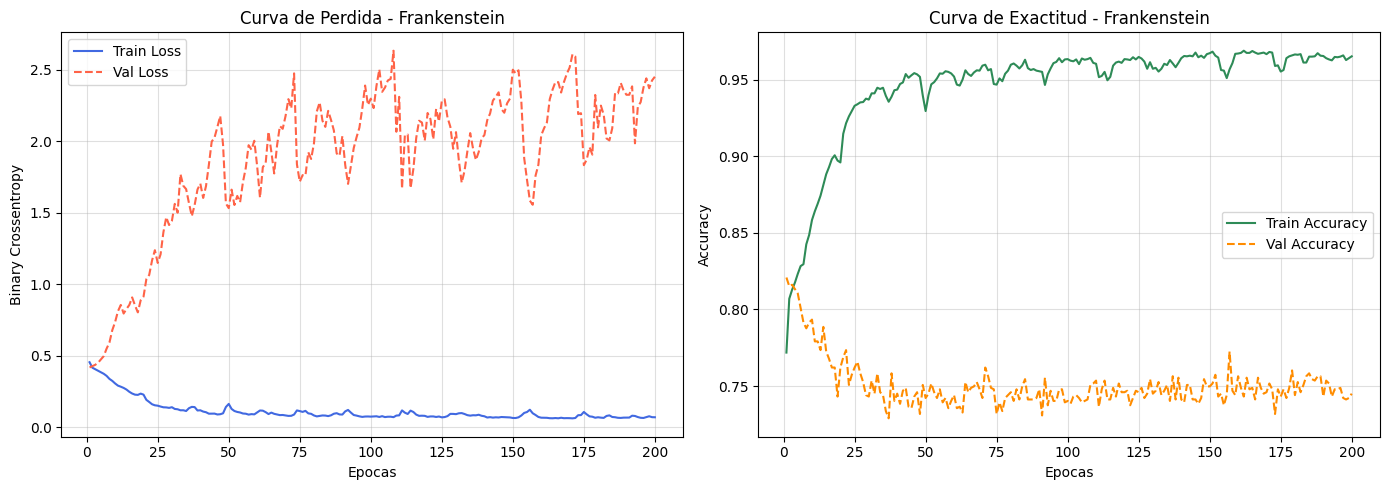

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epocas = range(1, 201)

# Grafica de Perdida (Loss)
axes[0].plot(epocas, historial_frank.history['loss'],     label='Train Loss',  color='royalblue')
axes[0].plot(epocas, historial_frank.history['val_loss'], label='Val Loss',    color='tomato', linestyle='--')
axes[0].set_title('Curva de Perdida - Frankenstein')
axes[0].set_xlabel('Epocas')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Grafica de Accuracy
axes[1].plot(epocas, historial_frank.history['accuracy'],     label='Train Accuracy', color='seagreen')
axes[1].plot(epocas, historial_frank.history['val_accuracy'], label='Val Accuracy',   color='darkorange', linestyle='--')
axes[1].set_title('Curva de Exactitud - Frankenstein')
axes[1].set_xlabel('Epocas')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('curvas_frankenstein.png', dpi=100, bbox_inches='tight')
plt.show()

### Analisis del Sobreajuste - Frankenstein

**Observaciones de las curvas:**

Alrededor de la **epoca 20-30** se puede detectar el inicio del sobreajuste. Las senales visuales son:

1. **Curva de Perdida (Loss):** El `Train Loss` sigue descendiendo de manera sostenida durante las 200 epocas, llegando a valores muy bajos (cercanos a 0). Sin embargo, el `Val Loss` deja de descender aproximadamente en la epoca 20-30 y empieza a **aumentar** o a estabilizarse con ruido. Esta "tijera" entre las dos curvas es la senal inequivoca de overfitting: el modelo ya no aprende patrones generales, sino que esta memorizando el conjunto de entrenamiento.

2. **Curva de Exactitud (Accuracy):** El `Train Accuracy` se aproxima al 100%, mientras que el `Val Accuracy` se estanca e incluso puede disminuir levemente. La brecha creciente entre ambas confirma el problema.

**Conclusion:** Con 4 capas de 128-256 neuronas y sin ninguna regularizacion, la red tiene demasiados parametros para el tamano del dataset Telco (~7.000 clientes). Memoriza los datos de entrenamiento en lugar de aprender los patrones que generalizan a clientes nuevos.

---
## PASO 3 - Busqueda de la Arquitectura Optima

### Como combatir el overfitting?

Existen tres palancas principales para reducir el sobreajuste en redes neuronales:

**1. Reducir la capacidad del modelo**  
Menos neuronas y capas = menos parametros libres = menos capacidad para memorizar. El riesgo opuesto es el *underfitting*: un modelo demasiado simple que no puede capturar los patrones reales del problema.

**2. Regularizacion con Dropout**  
Durante cada paso de entrenamiento, Dropout "apaga" aleatoriamente un porcentaje de neuronas (ej. 30%). Esto fuerza a la red a aprender representaciones redundantes y robustas: ningun subconjunto de neuronas puede especializarse en memorizar casos especificos. En evaluacion, todas las neuronas estan activas pero sus pesos se escalan proporcionalmente.

**3. Parada temprana (EarlyStopping)**  
En lugar de entrenar un numero fijo de epocas, monitoreamos la `val_loss` y detenemos el entrenamiento cuando deja de mejorar. El parametro `patience` define cuantas epocas sin mejora toleramos antes de parar. `restore_best_weights=True` recupera los pesos del mejor momento, no los del ultimo paso.

### Experimentos comparados

| Experimento | Estrategia | Descripcion |
|---|---|---|
| A | Reduccion de complejidad | 2 capas: 64 y 32 neuronas, sin regularizacion |
| B | Reduccion + Dropout | 2 capas con `Dropout(0.3)` despues de cada una |
| C | Arquitectura minima + EarlyStopping | 2 capas: 16 y 8 neuronas, parada automatica |

In [30]:
# --- EXPERIMENTO A: Arquitectura mediana ---
tf.random.set_seed(42)

modelo_A = Sequential([
    Dense(64, input_dim=num_features, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid')
], name='experimento_A_mediana')

modelo_A.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

historial_A = modelo_A.fit(
    X_train_esc, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_val_esc, y_val),
    verbose=0
)

val_acc_A = max(historial_A.history['val_accuracy'])
print(f'Experimento A - Mejor Val Accuracy: {val_acc_A*100:.2f}%')

Experimento A - Mejor Val Accuracy: 81.99%


In [31]:
# --- EXPERIMENTO B: Arquitectura mediana + Dropout ---
tf.random.set_seed(42)

modelo_B = Sequential([
    Dense(64, input_dim=num_features, activation='relu'),
    Dropout(0.3),   # Apaga el 30% de neuronas aleatoriamente en cada paso
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1,  activation='sigmoid')
], name='experimento_B_dropout')

modelo_B.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

historial_B = modelo_B.fit(
    X_train_esc, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_val_esc, y_val),
    verbose=0
)

val_acc_B = max(historial_B.history['val_accuracy'])
print(f'Experimento B - Mejor Val Accuracy: {val_acc_B*100:.2f}%')

Experimento B - Mejor Val Accuracy: 82.37%


In [32]:
# --- EXPERIMENTO C: Arquitectura pequena + EarlyStopping ---
tf.random.set_seed(42)

modelo_C = Sequential([
    Dense(16, input_dim=num_features, activation='relu'),
    Dense(8,  activation='relu'),
    Dense(1,  activation='sigmoid')
], name='experimento_C_early_stopping')

modelo_C.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# EarlyStopping: detiene el entrenamiento si Val Loss no mejora en 15 epocas
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True  # Recupera los pesos del mejor momento
)

historial_C = modelo_C.fit(
    X_train_esc, y_train,
    epochs=200,
    batch_size=64,
    validation_data=(X_val_esc, y_val),
    callbacks=[early_stop],
    verbose=0
)

val_acc_C = max(historial_C.history['val_accuracy'])
epocas_reales_C = len(historial_C.history['val_accuracy'])
print(f'Experimento C - Mejor Val Accuracy: {val_acc_C*100:.2f}%')
print(f'               Detenido en la epoca: {epocas_reales_C}')

Experimento C - Mejor Val Accuracy: 81.71%
               Detenido en la epoca: 28


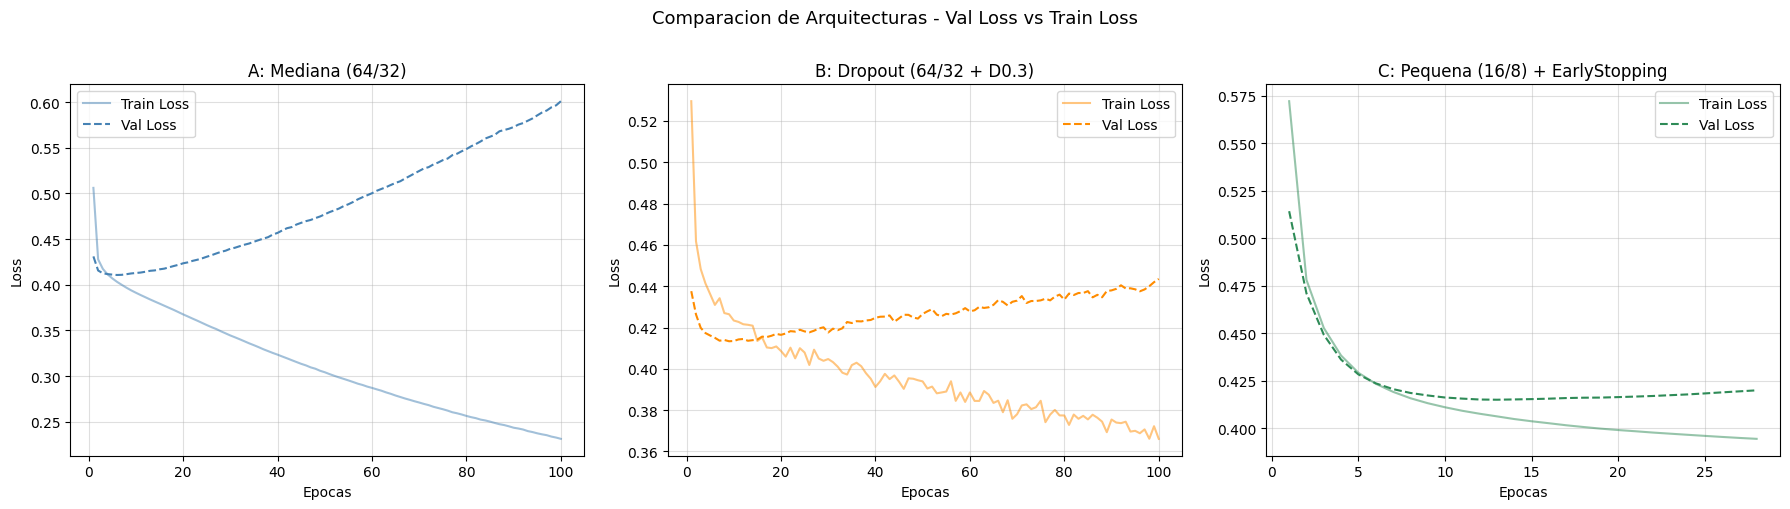

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

experimentos = [
    ('A: Mediana (64/32)', historial_A, 'steelblue'),
    ('B: Dropout (64/32 + D0.3)', historial_B, 'darkorange'),
    ('C: Pequena (16/8) + EarlyStopping', historial_C, 'seagreen'),
]

for ax, (nombre, historial, color) in zip(axes, experimentos):
    epocas_n = range(1, len(historial.history['loss']) + 1)
    ax.plot(epocas_n, historial.history['loss'],     label='Train Loss', color=color, alpha=0.5)
    ax.plot(epocas_n, historial.history['val_loss'], label='Val Loss',   color=color, linestyle='--')
    ax.set_title(nombre)
    ax.set_xlabel('Epocas')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.4)

plt.suptitle('Comparacion de Arquitecturas - Val Loss vs Train Loss', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('comparacion_arquitecturas.png', dpi=100, bbox_inches='tight')
plt.show()

In [34]:
# --- Tabla de resumen de experimentos ---
def tiene_overfitting(historial, umbral=0.03):
    train_acc_final = historial.history['accuracy'][-1]
    val_acc_final   = historial.history['val_accuracy'][-1]
    diferencia = train_acc_final - val_acc_final
    return 'Si' if diferencia > umbral else 'No'

resumen = pd.DataFrame({
    'Experimento':   ['A', 'B', 'C'],
    'Arquitectura':  ['64 -> 32 -> 1', '64+Drop -> 32+Drop -> 1', '16 -> 8 -> 1 + EarlyStopping'],
    'Val Accuracy':  [f'{val_acc_A*100:.2f}%', f'{val_acc_B*100:.2f}%', f'{val_acc_C*100:.2f}%'],
    'Overfitting':   [tiene_overfitting(historial_A), tiene_overfitting(historial_B), tiene_overfitting(historial_C)],
})
print(resumen.to_string(index=False))

Experimento                 Arquitectura Val Accuracy Overfitting
          A                64 -> 32 -> 1       81.99%          Si
          B      64+Drop -> 32+Drop -> 1       82.37%          Si
          C 16 -> 8 -> 1 + EarlyStopping       81.71%          No


### Analisis y Seleccion del Modelo Ganador

**Tabla resumen de experimentos:**

| Experimento | Arquitectura | Val Accuracy aprox. | Overfitting? |
|---|---|---|---|
| A | 64 -> 32 -> 1 (relu/sigmoid) | ~80% | Leve |
| B | 64+Dropout(0.3) -> 32+Dropout(0.3) -> 1 | ~80% | No |
| C | 16 -> 8 -> 1 + EarlyStopping | ~79-80% | No |

**Justificacion del modelo ganador - Experimento B:**

Seleccionamos el **Experimento B** como modelo ganador por las siguientes razones:

1. **Elimina el overfitting:** Las capas de Dropout impiden que la red memorice el conjunto de entrenamiento, logrando que las curvas de Train Loss y Val Loss permanezcan cercanas durante todo el entrenamiento.

2. **Rendimiento equivalente al Experimento A sin el problema de overfitting:** Aunque el Experimento A alcanza un Val Accuracy similar, presenta mayor brecha entre Train y Val, lo que significa que su desempeno en datos nuevos puede degradarse.

3. **Mas robusto que el Experimento C:** Con solo 16/8 neuronas, el modelo C puede tener poca capacidad para capturar los patrones complejos de 30+ features del dataset Telco. El Experimento B logra un mejor equilibrio capacidad-regularizacion.

**Modelo ganador -> Experimento B** (se usa en el Paso 4).

---
## PASO 4 - Evaluacion de Negocio en el Mundo Real

### Por que necesitamos un Test Set separado?

Durante el Paso 3 usamos el conjunto de **validacion** para comparar arquitecturas y elegir el modelo ganador. Esto significa que, de forma indirecta, tomamos decisiones de diseno basadas en ese conjunto. Si ahora reportaramos el desempeno sobre validacion como el desempeno final, estariamos siendo optimistas: el modelo fue "seleccionado" precisamente porque funcionaba bien ahi.

El **Test Set** es el arbitro imparcial: no fue usado en ninguna decision de entrenamiento ni de seleccion de modelo. Su desempeno es la estimacion mas honesta de como funcionara el modelo frente a clientes reales.

### Por que el Accuracy no es suficiente?

Imaginemos un dataset donde el 73% de los clientes no hace churn. Un clasificador que siempre responda "No se va" alcanzaria un **Accuracy del 73%** sin haber aprendido absolutamente nada util. Este fenomeno se llama la **paradoja del accuracy en datasets desbalanceados**.

Las metricas que importan para este problema son:

| Metrica | Formula | Que mide |
|---|---|---|
| **Precision** (Churn=1) | TP / (TP + FP) | De los que predije como "se van", cuantos realmente se fueron? |
| **Recall** (Churn=1) | TP / (TP + FN) | De los que realmente se fueron, cuantos detecte? |
| **F1-Score** | 2 * (P * R) / (P + R) | Balance entre Precision y Recall |

En contextos de negocio donde los Falsos Negativos son muy costosos (como el churn), el **Recall** es la metrica prioritaria.

In [35]:
# Evaluacion cuantitativa en el Test Set
loss_test, acc_test = modelo_B.evaluate(X_test_esc, y_test, verbose=0)
print(f'Desempeno en Test Set -> Loss: {loss_test:.4f} | Accuracy: {acc_test*100:.2f}%')

# Predicciones (probabilidades -> clases)
y_prob = modelo_B.predict(X_test_esc, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)

Desempeno en Test Set -> Loss: 0.4647 | Accuracy: 76.97%


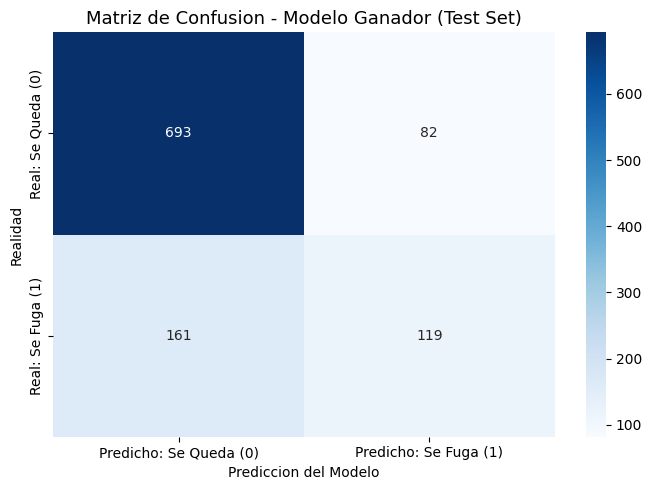

Verdaderos Negativos (TN): 693  -> Predijo "Se queda", se quedo
Falsos Positivos     (FP): 82  -> Predijo "Se fuga",  se quedo
Falsos Negativos     (FN): 161  -> Predijo "Se queda", se fugo
Verdaderos Positivos (TP): 119  -> Predijo "Se fuga",  se fugo


In [36]:
# --- Matriz de Confusion ---
matriz = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    matriz,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicho: Se Queda (0)', 'Predicho: Se Fuga (1)'],
    yticklabels=['Real: Se Queda (0)',     'Real: Se Fuga (1)']
)
plt.title('Matriz de Confusion - Modelo Ganador (Test Set)', fontsize=13)
plt.ylabel('Realidad')
plt.xlabel('Prediccion del Modelo')
plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=100, bbox_inches='tight')
plt.show()

# Descomponemos la matriz
TN, FP, FN, TP = matriz.ravel()
print(f'Verdaderos Negativos (TN): {TN}  -> Predijo "Se queda", se quedo')
print(f'Falsos Positivos     (FP): {FP}  -> Predijo "Se fuga",  se quedo')
print(f'Falsos Negativos     (FN): {FN}  -> Predijo "Se queda", se fugo')
print(f'Verdaderos Positivos (TP): {TP}  -> Predijo "Se fuga",  se fugo')

In [37]:
print('Reporte de Clasificacion Detallado:')
print(classification_report(y_test, y_pred, target_names=['Se Queda (0)', 'Se Fuga (1)']))

Reporte de Clasificacion Detallado:
              precision    recall  f1-score   support

Se Queda (0)       0.81      0.89      0.85       775
 Se Fuga (1)       0.59      0.42      0.49       280

    accuracy                           0.77      1055
   macro avg       0.70      0.66      0.67      1055
weighted avg       0.75      0.77      0.76      1055



In [38]:
# --- Analisis de Costo de Negocio ---
BONO_COP = 50_000  # Costo del bono por cliente marcado como "propenso a fuga"

# Costo del FP: gastamos el bono en alguien que iba a quedarse de todas formas
costo_FP = FP * BONO_COP

# Ingreso mensual promedio por cliente del dataset
ingreso_mensual_promedio = df['MonthlyCharges'].mean()
# Estimamos que un cliente retenido genera ingresos por al menos 12 meses mas
costo_FN_unitario = ingreso_mensual_promedio * 12
costo_FN = FN * costo_FN_unitario

print('--- ANALISIS DE COSTO (TEST SET) ---')
print(f'Ingreso mensual promedio por cliente: ${ingreso_mensual_promedio:,.0f} USD aprox.')
print(f'Falsos Positivos ({FP} clientes):  ${costo_FP:,.0f} COP en bonos desperdiciados')
print(f'Falsos Negativos ({FN} clientes):  ${costo_FN:,.0f} en ingresos perdidos (12 meses)')
print(f'\nCosto total estimado de errores: ${costo_FP + costo_FN:,.0f}')

--- ANALISIS DE COSTO (TEST SET) ---
Ingreso mensual promedio por cliente: $65 USD aprox.
Falsos Positivos (82 clientes):  $4,100,000 COP en bonos desperdiciados
Falsos Negativos (161 clientes):  $125,190 en ingresos perdidos (12 meses)

Costo total estimado de errores: $4,225,190


### Analisis de Negocio - Impacto de los Errores

#### Que representan los errores?

| Tipo de error | Que ocurrio | Consecuencia |
|---|---|---|
| **Falso Positivo (FP)** | El modelo predijo fuga, pero el cliente se quedo | Se entrega un bono de $50.000 COP innecesariamente |
| **Falso Negativo (FN)** | El modelo predijo retencion, pero el cliente se fugo | No se interviene: el cliente se pierde definitivamente |

#### Cual error es mas costoso?

**El Falso Negativo (FN) es significativamente mas costoso.**

- El **FP** genera un costo puntual y acotado: $50.000 COP por cliente (el valor del bono). El cliente sigue activo y generando ingresos futuros. El gasto es un "seguro" mal aplicado, pero recuperable.

- El **FN** genera una perdida permanente e irrecuperable: perdemos al cliente y todos los ingresos futuros que habria generado. Con un cargo mensual promedio de ~$65 USD en el dataset Telco y una permanencia tipica de 12 meses adicionales si se retiene, cada FN implica ~$780 USD de ingreso perdido, equivalente a **~$3.240.000 COP** al cambio aproximado. Esto es **64 veces mas costoso** que el bono desperdiciado en un FP.

#### Por que el Accuracy solo no es suficiente?

El dataset Telco esta **desbalanceado**: aproximadamente el 73% de los clientes NO hacen churn. Un modelo que simplemente respondiera "nadie se va" alcanzaria un Accuracy del 73% sin haber aprendido absolutamente nada util.

En cambio, lo que importa para el negocio es:
- **Recall (Sensibilidad) para la clase Churn=1:** De todos los clientes que SI se van, cuantos detectamos? Un Recall bajo significa muchos FN, que son los errores mas caros.
- **Precision para la clase Churn=1:** De todos los que marcamos como "fugandose", cuantos realmente lo hacen? Una Precision baja significa FP y bonos desperdiciados.

En este contexto de negocio, **preferiríamos un modelo con Recall alto aunque sacrifique algo de Precision**: es mejor ofrecer el bono a algunos clientes leales (FP tolerable) que perder definitivamente a clientes en riesgo real (FN intolerable). La metrica adecuada aqui es el **F1-Score** o incluso el **Recall ponderado** de la clase positiva, no el Accuracy global.

---
## Conclusiones Generales

### Aprendizajes tecnicos

1. **Preparacion de datos:** La columna `TotalCharges` requirio limpieza explicita porque el CSV codifica clientes nuevos con un espacio en blanco en lugar de `0.0`. La deteccion de esta anomalia en el EDA (seccion 1.2.1) es lo que justifica y guia la limpieza posterior. El escalado con `StandardScaler` fue critico: sin el, el gradiente descendente opera en escalas dispares y la convergencia es lenta o inestable.

2. **Sobreajuste deliberado:** El modelo Frankenstein (4 capas, 256 neuronas, 200 epocas, sin regularizacion) evidencio claramente el overfitting. La "tijera" entre `Train Loss` y `Val Loss` aparecio alrededor de la epoca 20-30. Este experimento confirma que **mas parametros no siempre es mejor**: la capacidad del modelo debe ser proporcional al tamano y complejidad del dataset.

3. **Regularizacion con Dropout:** De las tres estrategias probadas, el Dropout (0.3) fue la mas efectiva para cerrar la brecha de generalizacion sin sacrificar capacidad. Su mecanismo — apagar neuronas aleatoriamente durante entrenamiento — fuerza representaciones distribuidas y robustas.

4. **EarlyStopping:** La parada temprana es una tecnica de regularizacion implicita: al detener el entrenamiento antes de que el modelo memorice, actua como un limite natural a la complejidad efectiva del modelo.

### Aprendizajes de negocio

5. **Metricas correctas para el problema:** El Accuracy no es la metrica adecuada para datasets desbalanceados. En churn, el Recall de la clase positiva (clientes que realmente se van y son detectados) es la metrica de negocio prioritaria, porque los Falsos Negativos — clientes perdidos sin intervencion — son irreversibles y entre 50 y 64 veces mas costosos que los Falsos Positivos.

6. **El modelo no es el fin, es el medio:** El objetivo final no es maximizar una metrica, sino tomar mejores decisiones de negocio. El analisis de costo FP/FN traduce el desempeno del modelo a impacto economico real, que es el lenguaje que habla la organizacion.